# Sentiment Analysis Multi-Kategori UMKMentor Menggunakan TF-IDF dan Linear SVM
**Deskripsi Proyek:**

Proyek ini bertujuan membangun model Sentiment Analysis untuk mengklasifikasikan sentimen ulasan pelanggan pada platform UMKMentor ke dalam tiga kelas, yaitu positif, netral, dan negatif. Dataset yang digunakan merupakan gabungan ulasan produk dari tujuh kategori utama, yaitu elektronik, pertukangan, olahraga, hiburan, fashion, kecantikan, serta makanan dan minuman. Informasi kategori digabungkan dengan teks ulasan sehingga model dapat memahami konteks produk yang sedang dianalisis.

Pada eksperimen ini digunakan pendekatan TF-IDF (Term Frequency–Inverse Document Frequency) sebagai metode ekstraksi fitur teks dan Linear Support Vector Machine (Linear SVM) sebagai algoritma klasifikasi. Model ini dipilih karena memiliki ukuran yang relatif kecil, proses pelatihan yang cepat, serta lebih ringan untuk diintegrasikan ke lingkungan backend dibandingkan model berbasis transformer seperti IndoBERT.

Model dievaluasi menggunakan metrik Accuracy, Weighted F1-Score, dan Macro F1-Score. Hasil evaluasi menunjukkan bahwa model TF-IDF + Linear SVM memperoleh Accuracy sebesar 86,19%, Weighted F1-Score sebesar 86,27%, dan Macro F1-Score sebesar 69,68%. Oleh karena itu, model ini dapat dijadikan alternatif deployment apabila terdapat keterbatasan sumber daya komputasi atau ukuran model pada proses integrasi sistem.

# A. Import Library

In [5]:
!pip install pandas numpy scikit-learn matplotlib joblib -q

import pandas as pd
import numpy as np
import re
import ast
import html
import os
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)
from sklearn.utils.class_weight import compute_class_weight

# B. Load Data Scraping

In [6]:
base_path = "/kaggle/input/datasets/adindaintanerlita/dataset-umkmentor/"

df = pd.read_csv(
    base_path + "all_category.csv"
)

with open(
    base_path + "slangwords.csv",
    "r",
    encoding="utf-8"
) as f:
    slang_dict = ast.literal_eval(f.read())

print(df.head())
print("\nJumlah Data:", len(df))
print("\nKolom:")
print(df.columns)
print("\nMissing Value:")
print(df.isnull().sum())

   Unnamed: 0                                               name     category  \
0       18110  Headset Gaming Sades T-Power Gaming Headset / ...   elektronik   
1       32264  Durable Cairan Tikus Mobil Rat Repellent Rumah...  pertukangan   
2       36952     Lem Karet Bat Pingpong Butterfly Free Chack II     olahraga   
3       24201  [SONIC GEAR] NEW TITAN 5 BTMI Multimedia Speak...   elektronik   
4       34268             DHS 2002 Bet Bat pingpong / tenis meja     olahraga   

                                              review  rating    target  
0                          Kualitas ok\nPelayanan ok       5  Positive  
1  kemasan bagus,pengiriman dan respon oke semoga...       5  Positive  
2                           Ok paket sampaii tks gan       5  Positive  
3             Produk sangat bagus, seller top banget       5  Positive  
4  .................................................       5  Positive  

Jumlah Data: 69975

Kolom:
Index(['Unnamed: 0', 'name', 'category', 'revie

# C. Exploratory Data Analysis (EDA)

In [7]:
df = df.drop(
    columns=["Unnamed: 0"],
    errors="ignore"
)

print("Ukuran dataset:", df.shape)

print("\nJumlah kategori:")
print(df["category"].nunique())

print("\nDistribusi kategori:")
print(df["category"].value_counts())

print("\nDistribusi target:")
print(df["target"].value_counts())

print("\nReview kosong:")
print(
    (df["review"].astype(str).str.strip() == "").sum()
)

print("\nDuplikasi:")
print(df.duplicated().sum())

Ukuran dataset: (69975, 5)

Jumlah kategori:
7

Distribusi kategori:
category
elektronik         10000
pertukangan        10000
olahraga           10000
hiburan            10000
fashion            10000
kecantikan          9997
makanan_minuman     9978
Name: count, dtype: int64

Distribusi target:
target
Positive    53140
Negative     8689
Neutral      8146
Name: count, dtype: int64

Review kosong:
0

Duplikasi:
0


# D. Preprocessing

In [8]:
emoji_dict = {
    "😊": "senang", "😁": "senang", "😍": "suka",
    "🥰": "suka", "😭": "kecewa", "😢": "sedih",
    "😡": "marah", "😤": "kesal", "🤩": "senang",
    "🔥": "bagus", "👍": "bagus", "👎": "jelek",
    "💔": "kecewa", "❤️": "suka", "❤": "suka",
    "🙏": "terima kasih", "⭐": "bagus"
}

def clean_text(text):

    text = str(text).lower()

    text = html.unescape(text)

    text = re.sub(r'\\n|\\t|\\r|\\b|\\f|\\v', ' ', text)
    text = re.sub(r'\\u[0-9a-fA-F]{4}', ' ', text)
    text = re.sub(r'\\x[0-9a-fA-F]{2}', ' ', text)

    text = re.sub(r'http\S+|www\S+', '', text)

    for emo, meaning in emoji_dict.items():
        text = text.replace(emo, " " + meaning + " ")

    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    words = text.split()
    words = [slang_dict.get(w, w) for w in words]

    text = " ".join(words)

    text = re.sub(r'\s+', ' ', text).strip()

    return text


df = df.dropna(
    subset=["category", "review", "target"]
)

df["category"] = (
    df["category"]
    .astype(str)
    .str.strip()
    .str.lower()
)

df["review"] = (
    df["review"]
    .astype(str)
    .str.strip()
)

df = df[
    df["review"] != ""
]

df["text_input"] = (
    "kategori "
    + df["category"].astype(str)
    + " ulasan "
    + df["review"].astype(str)
)

df["clean_text"] = (
    df["text_input"]
    .apply(clean_text)
)

df = df[
    df["clean_text"] != ""
]

df = df[
    df["clean_text"]
    .str.split()
    .str.len() >= 5
]

print(df[["category", "review", "clean_text", "target"]].head())

print("\nJumlah data setelah preprocessing:")
print(len(df))

print("\nDistribusi target:")
print(df["target"].value_counts())

      category                                             review  \
0   elektronik                          Kualitas ok\nPelayanan ok   
1  pertukangan  kemasan bagus,pengiriman dan respon oke semoga...   
2     olahraga                           Ok paket sampaii tks gan   
3   elektronik             Produk sangat bagus, seller top banget   
5  pertukangan  kualitas barang jelek, lubang baud jebol tidak...   

                                          clean_text    target  
0  kategori elektronik ulasan kualitas oke pelaya...  Positive  
1  kategori pertukangan ulasan kemasan bagus peng...  Positive  
2  kategori olahraga ulasan oke paket sampaii ter...  Positive  
3  kategori elektronik ulasan produk sangat bagus...  Positive  
5  kategori pertukangan ulasan kualitas barang je...  Negative  

Jumlah data setelah preprocessing:
67200

Distribusi target:
target
Positive    50891
Negative     8503
Neutral      7806
Name: count, dtype: int64


# E. Labeling

In [9]:
df["sentiment"] = df["target"].str.lower()

df["sentiment"] = df["sentiment"].replace({
    "positive": "positif",
    "neutral": "netral",
    "negative": "negatif"
})

label_map = {
    "negatif": 0,
    "netral": 1,
    "positif": 2
}

sentiment_map = {
    0: "negatif",
    1: "netral",
    2: "positif"
}

df["label"] = df["sentiment"].map(label_map)

print("Distribusi Sentimen:")
print(df["sentiment"].value_counts())

print("\nDistribusi Label:")
print(df["label"].value_counts())

Distribusi Sentimen:
sentiment
positif    50891
negatif     8503
netral      7806
Name: count, dtype: int64

Distribusi Label:
label
2    50891
0     8503
1     7806
Name: count, dtype: int64


# F. Split Data

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print("Jumlah train:", len(X_train))
print("Jumlah test :", len(X_test))

print("\nDistribusi Train:")
print(y_train.value_counts())

print("\nDistribusi Test:")
print(y_test.value_counts())

Jumlah train: 53760
Jumlah test : 13440

Distribusi Train:
label
2    40713
0     6802
1     6245
Name: count, dtype: int64

Distribusi Test:
label
2    10178
0     1701
1     1561
Name: count, dtype: int64


# G. TF-IDF Vectorization

In [11]:
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Shape Train:", X_train_tfidf.shape)
print("Shape Test :", X_test_tfidf.shape)

Shape Train: (53760, 35002)
Shape Test : (13440, 35002)


# H. Class Weight

In [12]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = {
    cls: weight
    for cls, weight in zip(
        np.unique(y_train),
        class_weights
    )
}

print("Class Weight:")
print(class_weight_dict)

Class Weight:
{np.int64(0): np.float64(2.6345192590414586), np.int64(1): np.float64(2.8694955964771816), np.int64(2): np.float64(0.44015425048510304)}


# I. Training Linear SVM

In [13]:
svm_model = LinearSVC(
    class_weight=class_weight_dict,
    C=1.0,
    max_iter=5000,
    random_state=42
)

svm_model.fit(
    X_train_tfidf,
    y_train
)

y_pred = svm_model.predict(
    X_test_tfidf
)

print("Training selesai.")

Training selesai.


# J. Training

In [14]:
print("\nCLASSIFICATION REPORT:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "negatif",
            "netral",
            "positif"
        ]
    )
)

print("\nCONFUSION MATRIX:")
print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

f1_weighted = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

f1_macro = f1_score(
    y_test,
    y_pred,
    average="macro"
)

print("\nHASIL EVALUASI:")
print("Accuracy     :", round(accuracy, 4))
print("Weighted F1  :", round(f1_weighted, 4))
print("Macro F1     :", round(f1_macro, 4))


CLASSIFICATION REPORT:
              precision    recall  f1-score   support

     negatif       0.64      0.69      0.66      1701
      netral       0.48      0.47      0.47      1561
     positif       0.96      0.95      0.96     10178

    accuracy                           0.86     13440
   macro avg       0.69      0.70      0.70     13440
weighted avg       0.86      0.86      0.86     13440


CONFUSION MATRIX:
[[1168  444   89]
 [ 521  729  311]
 [ 136  355 9687]]

HASIL EVALUASI:
Accuracy     : 0.8619
Weighted F1  : 0.8627
Macro F1     : 0.6968


# K. Error Analisis

In [15]:
error_df = pd.DataFrame({
    "text": X_test.values,
    "true_label": y_test.values,
    "pred_label": y_pred
})

error_df["true_sentiment"] = (
    error_df["true_label"]
    .map(sentiment_map)
)

error_df["pred_sentiment"] = (
    error_df["pred_label"]
    .map(sentiment_map)
)

wrong_predictions = error_df[
    error_df["true_sentiment"]
    != error_df["pred_sentiment"]
]

print("Jumlah Salah Prediksi:")
print(len(wrong_predictions))

print("\nContoh Salah Prediksi:")
print(
    wrong_predictions[
        [
            "text",
            "true_sentiment",
            "pred_sentiment"
        ]
    ].head(20)
)

print("\nPola Kesalahan:")
print(
    wrong_predictions
    .groupby(
        [
            "true_sentiment",
            "pred_sentiment"
        ]
    )
    .size()
    .sort_values(
        ascending=False
    )
)

Jumlah Salah Prediksi:
1856

Contoh Salah Prediksi:
                                                  text true_sentiment  \
1    kategori hiburan ulasan alhamdulillah tidak ad...        positif   
6    kategori olahraga ulasan barang sesuai dengan ...        positif   
7    kategori fashion ulasan pesanan sudah sampai t...         netral   
19   kategori kecantikan ulasan di pakai jadi kayak...        negatif   
23   kategori kecantikan ulasan dipake bagus tidak ...        positif   
47   kategori fashion ulasan lumayan sudah buat kol...        negatif   
56   kategori kecantikan ulasan sering banget muncu...        positif   
62   kategori olahraga ulasan barang sudah diterima...         netral   
67   kategori fashion ulasan anting emas tidak leng...        negatif   
72   kategori hiburan ulasan terlambat di kurirnya ...        positif   
73   kategori olahraga ulasan sudah nunggu beberapa...         netral   
75   kategori fashion ulasan bahan lumayan dengan h...        positif   

# L. Visualisasi Confusion Matrix

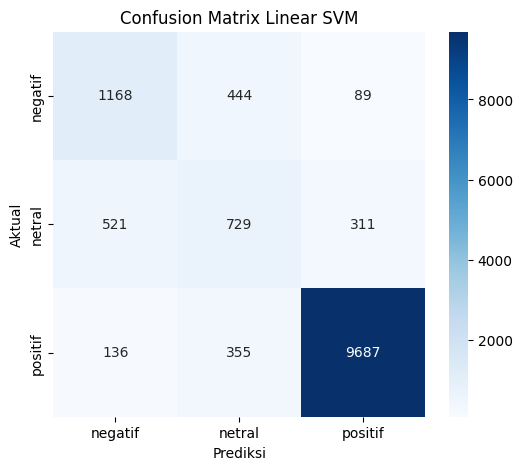

In [16]:
import seaborn as sns

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "negatif",
        "netral",
        "positif"
    ],
    yticklabels=[
        "negatif",
        "netral",
        "positif"
    ]
)

plt.title(
    "Confusion Matrix Linear SVM"
)

plt.xlabel(
    "Prediksi"
)

plt.ylabel(
    "Aktual"
)

plt.show()

# M. Simpan Model

In [17]:
joblib.dump(
    svm_model,
    "svm_umkmentor_all_category.pkl"
)

joblib.dump(
    tfidf,
    "tfidf_umkmentor_all_category.pkl"
)

joblib.dump(
    label_map,
    "label_map.pkl"
)

print("Model berhasil disimpan")

Model berhasil disimpan


# N. Inferene

In [18]:
def predict_sentiment_svm(
    text,
    category
):

    text_input = (
        "kategori "
        + str(category)
        + " ulasan "
        + str(text)
    )

    text_clean = clean_text(
        text_input
    )

    text_tfidf = tfidf.transform(
        [text_clean]
    )

    pred = svm_model.predict(
        text_tfidf
    )[0]

    return sentiment_map[pred]

# O. Pengujian 7 Kategori

In [20]:
samples = [

    ("makanan_minuman",
     "Rasanya enak dan pengiriman cepat"),

    ("makanan_minuman",
     "Makanan basi dan tidak layak dimakan"),

    ("hiburan",
     "Bukunya sangat menarik dan berkualitas"),

    ("hiburan",
     "Isi buku mengecewakan dan banyak halaman rusak"),

    ("elektronik",
     "Barang berfungsi dengan baik"),

    ("elektronik",
     "Produk rusak setelah dua hari"),

    ("olahraga",
     "Raket nyaman digunakan"),

    ("olahraga",
     "Grip mudah lepas dan kualitas buruk"),

    ("pertukangan",
     "Bor sangat kuat dan tahan lama"),

    ("pertukangan",
     "Bor cepat panas dan tidak sesuai deskripsi"),

    ("fashion",
     "Bahan nyaman dan jahitan rapi"),

    ("fashion",
     "Bahan tipis dan warna berbeda"),

    ("kecantikan",
     "Produk original dan cocok di kulit"),

    ("kecantikan",
     "Menyebabkan iritasi dan sangat mengecewakan")
]

for category, review in samples:

    hasil = predict_sentiment_svm(
        review,
        category
    )

    print(
        f"Kategori: {category}"
    )

    print(
        f"Review   : {review}"
    )

    print(
        f"Sentimen : {hasil}"
    )

    print("-" * 60)

Kategori: makanan_minuman
Review   : Rasanya enak dan pengiriman cepat
Sentimen : positif
------------------------------------------------------------
Kategori: makanan_minuman
Review   : Makanan basi dan tidak layak dimakan
Sentimen : negatif
------------------------------------------------------------
Kategori: hiburan
Review   : Bukunya sangat menarik dan berkualitas
Sentimen : positif
------------------------------------------------------------
Kategori: hiburan
Review   : Isi buku mengecewakan dan banyak halaman rusak
Sentimen : negatif
------------------------------------------------------------
Kategori: elektronik
Review   : Barang berfungsi dengan baik
Sentimen : positif
------------------------------------------------------------
Kategori: elektronik
Review   : Produk rusak setelah dua hari
Sentimen : negatif
------------------------------------------------------------
Kategori: olahraga
Review   : Raket nyaman digunakan
Sentimen : positif
------------------------------------